# Exact numerical calculation of reflection, transmission, and absorption spectra of a spectroscopic cell filled with an atomic vapor 

We consider the linear response of an atomic vapor layer of thickness $l$ confined between two dielectric windows for the case of quenching atom-wall collisions. The spectra are computed exactly in the optical density $m$ without the use of the perturbation theory. The model is valid for any vapor layer thickness $l$, however, longer cells require more time to perform accurate simulations.

All the physics is in [`tvl.py`](tvl.py). This notebook sets the parameters, computes the spectra and plots them. The [README](README.md) describes the model, the conventions and the accuracy.

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tvl

## Parameters

All quantities are dimensionless; frequencies are in units of the Doppler width $k v_T$.

In [2]:
l_lam = 5 / 3                          # layer thickness l / lambda
Gamma = 0.01                           # homogeneous half-width gamma / (k v_T)
m     = 0.002                          # optical density 2 sqrt(pi) N d^2 / (hbar k v_T)
n1    = 1.5                            # front window (the light comes from here)
n2    = 1.5                            # rear window
Omega = np.linspace(-15, 15, 101) * Gamma   # detuning (omega - omega_0) / (k v_T)
N     = None                           # grid intervals across the vapor layer; None -> tvl.grid_size(l_lam)

## Spectra

One linear solve per detuning. The cost grows as $N^3$: about 0.1-0.2 s per detuning for $l = 5\lambda/3$ ($N = 168$).

In [3]:
t0 = time.time()
R, T, A = tvl.spectra(l_lam, Omega, Gamma, m, n1, n2, N=N)
print(f'{Omega.size} detunings, N = {N or tvl.grid_size(l_lam)}: {time.time() - t0:.1f} s')

101 detunings, N = 168: 10.7 s


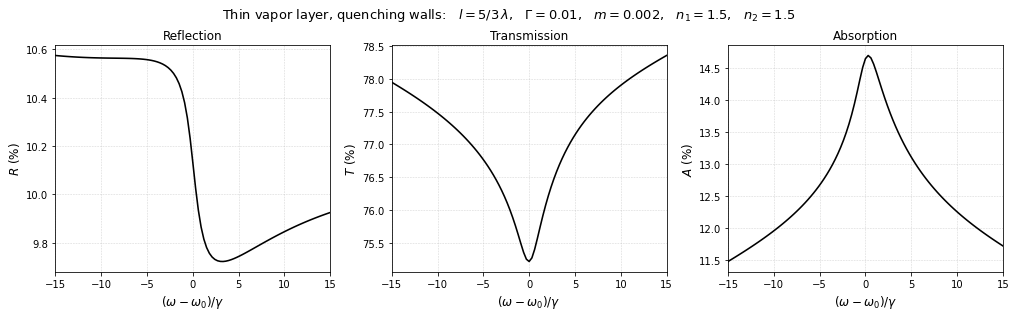

In [4]:
fig, axes = tvl.plot_spectra(Omega, R, T, A, l_lam, Gamma, m, n1, n2)
Path('figures').mkdir(exist_ok=True)
fig.savefig('figures/example_spectra.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

## Check numerics: empty cell

In the absence of the vapor ($m = 0$) nothing is absorbed, so $R + T = 1$ must hold.

In [5]:
R0, T0, A0 = tvl.spectra(l_lam, Omega[:3], Gamma, 0.0, n1, n2, N=N)
print(f'empty cell: max |1 - R - T| = {np.abs(A0).max():.1e}')

empty cell: max |1 - R - T| = 2.2e-16
